In [1]:
import numpy as np
import pandas as pd
from lets_plot import *


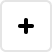
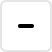
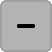
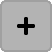
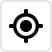
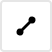
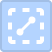
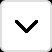
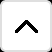
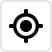
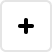
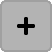
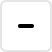
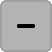
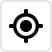
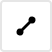
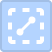
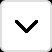
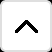
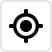

In [2]:
LetsPlot.setup_html()

In [3]:
climate_data = pd.read_csv("https://raw.githubusercontent.com/JetBrains/lets-plot-docs/refs/heads/master/data/delhi_climate.csv")
climate_data['date'] = pd.to_datetime(climate_data['date'])
climate_data.head(3)

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.5,0.000000,1015.666667
1,2013-01-02,7.400000,92.0,2.980000,1017.800000
2,2013-01-03,7.166667,87.0,4.633333,1018.666667


In [4]:
temperature_plot = (
    ggplot(climate_data) + geom_line(aes('date', 'meantemp', color='meantemp')) 
    + scale_color_gradient2(low='#0571b0', mid='#f7f7f7', high='#ca0020', midpoint=30)
)
temperature_plot

In [5]:
# Synthetic: Daily cost with a temperature-based surge
def calculate_daily_cost(t):
    base_cost = 1.5
    surge = 0
    
    if t > 30:
        # Sharp surge above 30 degrees
        surge = 0.15 * ((t - 30) ** 2)
        
    return base_cost + surge

In [6]:
# Monthly cost data (synthetic)
cost_data = (
    climate_data.assign(daily_cost=climate_data['meantemp'].apply(calculate_daily_cost))
    .resample('MS', on='date')
    .agg(
        avg_daily_cost=('daily_cost', 'mean'),
        min_daily_cost=('daily_cost', 'min'),
        max_daily_cost=('daily_cost', 'max'),
        total_monthly_bill=('daily_cost', 'sum') # Useful for a different plot
    )
    .reset_index()
)

cost_data.head(3)

,date,avg_daily_cost,min_daily_cost,max_daily_cost,total_monthly_bill
0,2013-01-01,1.5,1.5,1.5,46.5
1,2013-02-01,1.5,1.5,1.5,42.0
2,2013-03-01,1.5,1.5,1.5,46.5


In [7]:
cost_plot = ggplot(cost_data) +\
    geom_bar(aes('date', 'avg_daily_cost'), stat='identity',
             fill='#F39C12', alpha=0.4) +\
    geom_pointrange(aes('date', 'avg_daily_cost', ymin='min_daily_cost', ymax='max_daily_cost'),
                    color='#A04000', fatten=3, size=0.8
                   )

cost_plot

In [8]:
ggdeck([
    temperature_plot + theme(legend_position='none') + labs(y='Mean Temperature [°C]'),
    cost_plot + scale_y_continuous(position='right') + labs(y='Daily Ice Cream Cost per Kid [$]'),
]) +\
theme(
    plot_title=element_text(hjust=0.5, size=21),
    panel_grid=element_line(),
    axis_title_x='blank'
) +\
ggtitle('Delhi Mean Temperature & Ice Cream Costs') +\
ggsize(800, 400)

In [9]:
# Tooltips

cost_plot2 = ggplot(cost_data) +\
    geom_bar(aes('date', 'avg_daily_cost'), stat='identity', 
             fill='#F39C12', alpha=0.4,
             tooltips='none'           # <-- Remove tooltips
            ) +\
    geom_pointrange(aes('date', 'avg_daily_cost', ymin='min_daily_cost', ymax='max_daily_cost'),
                    color='#A04000', fatten=3, size=0.8,
                    tooltips=layer_tooltips()
                        .title('@date')
                        .line('Avg | ^y')
                        .line('Min | ^ymin')
                        .line('Max | ^ymax')
                        .format('^Y', '${.2f}')
                        .format('@date', '%b')
                        .anchor('top_right')    # <-- Show tooltips in the corner
                   )

cost_plot2 + ggsize(800, 400) + theme()

In [10]:
ggdeck([
    temperature_plot + theme(legend_position='none') + labs(y='Mean Temperature [°C]'),
    cost_plot2 + scale_y_continuous(position='right') + labs(y='Daily Ice Cream Cost per Kid [$]'),
]) +\
theme(
    plot_title=element_text(hjust=0.5, size=21),
    panel_grid=element_line(),
    axis_title_x='blank'
) +\
ggtitle('Delhi Mean Temperature & Ice Cream Costs') +\
ggsize(800, 400)